# 02 — Analyse des Résultats de Clustering

**Sprint 2** — Daniel (Data Engineer)

Ce notebook visualise les résultats du pipeline de clustering :
1. Métriques d'évaluation (silhouette, inertia, courbe du coude)
2. Distribution des segments clients
3. Distribution des segments producteurs
4. Profils des clusters (heatmap des centroïdes)

In [1]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(Path("../..") / ".env")

engine = create_engine(
    f"postgresql://{os.getenv('POSTGRES_USER')}:{os.getenv('POSTGRES_PASSWORD')}"
    f"@{os.getenv('POSTGRES_HOST', 'localhost')}:{os.getenv('POSTGRES_PORT', 5432)}"
    f"/{os.getenv('POSTGRES_DB')}"
)

def query(sql):
    return pd.read_sql(sql, engine)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 1. Historique des exécutions

In [2]:
runs = query("SELECT * FROM clustering_runs ORDER BY id DESC")
runs

,id,run_type,started_at,finished_at,n_clusters,silhouette_score,inertia,parameters,status
0,4,producer,2026-03-23 16:29:47.675522+00:00,2026-03-23 16:29:47.735954+00:00,2,0.2912,781.97,"{'n_init': 10, 'scaler': 'StandardScaler', 'k_...",success
1,3,customer,2026-03-23 16:29:47.394518+00:00,2026-03-23 16:29:47.586858+00:00,3,0.2124,3972.29,"{'n_init': 10, 'scaler': 'StandardScaler', 'k_...",success
2,2,producer,2026-03-23 16:28:56.424991+00:00,2026-03-23 16:28:56.484392+00:00,2,0.2912,781.97,"{'n_init': 10, 'scaler': 'StandardScaler', 'k_...",success
3,1,customer,2026-03-23 16:28:56.050565+00:00,2026-03-23 16:28:56.302869+00:00,3,0.2124,3972.29,"{'n_init': 10, 'scaler': 'StandardScaler', 'k_...",success


## 2. Courbe du coude & Silhouette (Clients)

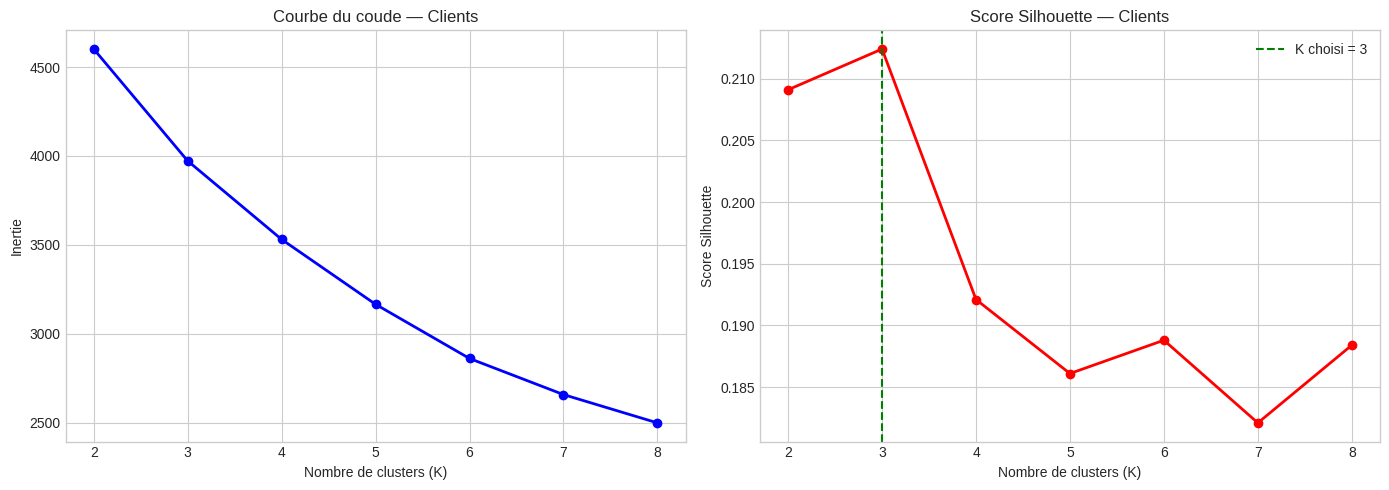

K optimal : 3
Silhouette score : 0.2124


In [3]:
# Récupérer les métriques du dernier run client
customer_run = runs[runs["run_type"] == "customer"].iloc[0]
params = customer_run["parameters"] if isinstance(customer_run["parameters"], dict) else json.loads(customer_run["parameters"])
metrics = params["metrics"]

ks = sorted([int(k) for k in metrics.keys()])
silhouettes = [metrics[str(k)]["silhouette"] for k in ks]
inertias = [metrics[str(k)]["inertia"] for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks, inertias, "bo-", linewidth=2)
ax1.set_xlabel("Nombre de clusters (K)")
ax1.set_ylabel("Inertie")
ax1.set_title("Courbe du coude — Clients")
ax1.set_xticks(ks)

ax2.plot(ks, silhouettes, "ro-", linewidth=2)
ax2.set_xlabel("Nombre de clusters (K)")
ax2.set_ylabel("Score Silhouette")
ax2.set_title("Score Silhouette — Clients")
ax2.set_xticks(ks)
ax2.axvline(x=customer_run["n_clusters"], color="green", linestyle="--",
            label=f"K choisi = {customer_run['n_clusters']}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"K optimal : {customer_run['n_clusters']}")
print(f"Silhouette score : {customer_run['silhouette_score']}")

## 3. Distribution des segments clients

Total clients segmentés : 1000

cluster_label
Fideles premium           408
Acheteurs occasionnels    387
Clients dormants          205
Name: count, dtype: int64



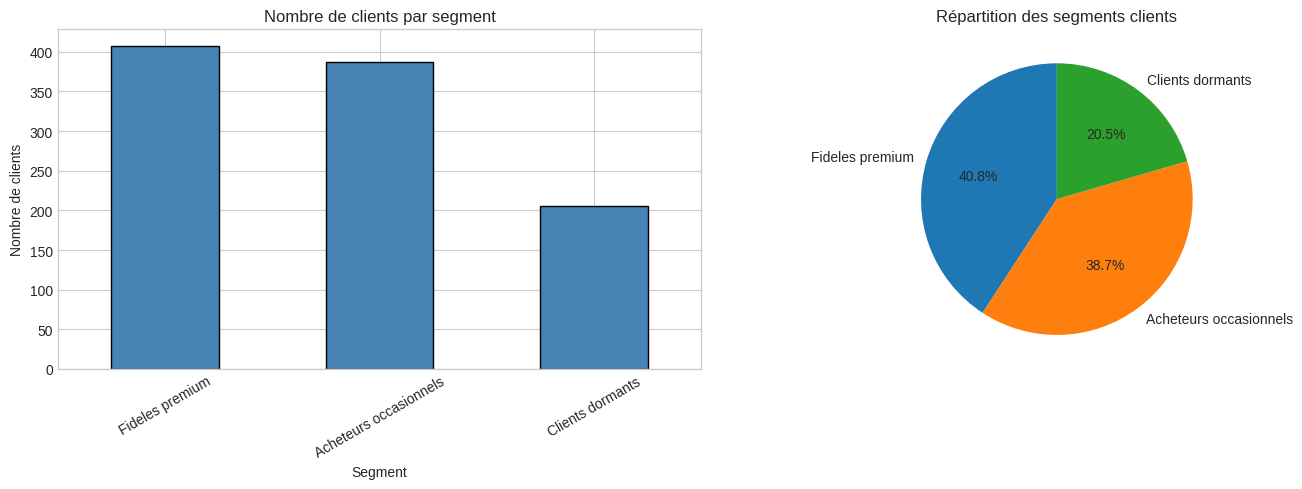

In [4]:
customers = query("SELECT * FROM v_current_customer_segments")
print(f"Total clients segmentés : {len(customers)}")
print()

dist = customers["cluster_label"].value_counts()
print(dist)
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dist.plot(kind="bar", ax=ax1, color="steelblue", edgecolor="black")
ax1.set_title("Nombre de clients par segment")
ax1.set_xlabel("Segment")
ax1.set_ylabel("Nombre de clients")
ax1.tick_params(axis="x", rotation=30)

dist.plot(kind="pie", ax=ax2, autopct="%1.1f%%", startangle=90)
ax2.set_ylabel("")
ax2.set_title("Répartition des segments clients")

plt.tight_layout()
plt.show()

## 4. Profil moyen des clusters clients (heatmap)

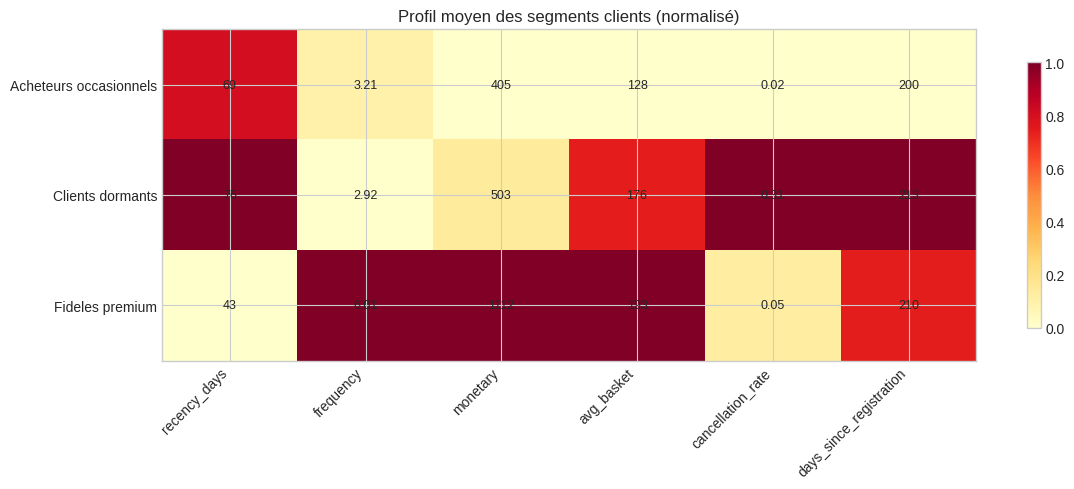

,recency_days,frequency,monetary,avg_basket,cancellation_rate,days_since_registration
cluster_label,,,,,,
Acheteurs occasionnels,69.17,3.21,404.59,128.22,0.02,199.92
Clients dormants,75.59,2.92,502.71,176.42,0.31,213.31
Fideles premium,43.12,6.01,1111.64,193.18,0.05,209.86


In [5]:
features = ["recency_days", "frequency", "monetary", "avg_basket",
            "cancellation_rate", "days_since_registration"]

profiles = customers.groupby("cluster_label")[features].mean()

# Normaliser pour la heatmap (min-max par colonne)
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min())

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(profiles_norm.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_yticks(range(len(profiles)))
ax.set_yticklabels(profiles.index)
ax.set_title("Profil moyen des segments clients (normalisé)")

# Annoter avec les valeurs réelles
for i in range(len(profiles)):
    for j in range(len(features)):
        val = profiles.values[i, j]
        fmt = ".0f" if val > 10 else ".2f"
        ax.text(j, i, f"{val:{fmt}}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

profiles.round(2)

## 5. Courbe du coude & Silhouette (Producteurs)

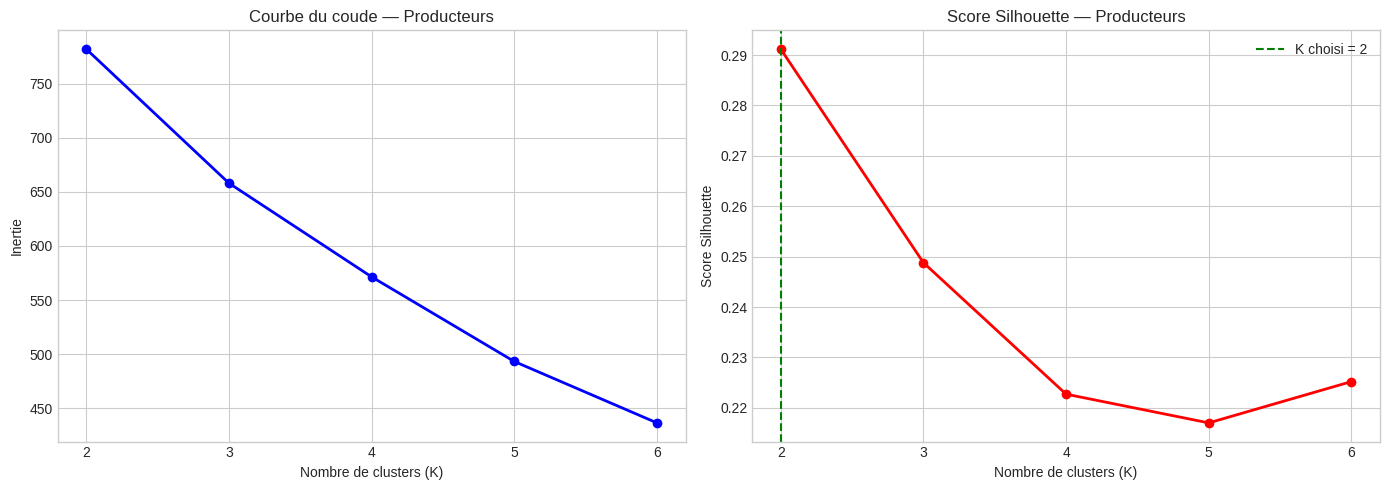

K optimal : 2
Silhouette score : 0.2912


In [6]:
producer_run = runs[runs["run_type"] == "producer"].iloc[0]
params_p = producer_run["parameters"] if isinstance(producer_run["parameters"], dict) else json.loads(producer_run["parameters"])
metrics_p = params_p["metrics"]

ks_p = sorted([int(k) for k in metrics_p.keys()])
silhouettes_p = [metrics_p[str(k)]["silhouette"] for k in ks_p]
inertias_p = [metrics_p[str(k)]["inertia"] for k in ks_p]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks_p, inertias_p, "bo-", linewidth=2)
ax1.set_xlabel("Nombre de clusters (K)")
ax1.set_ylabel("Inertie")
ax1.set_title("Courbe du coude — Producteurs")
ax1.set_xticks(ks_p)

ax2.plot(ks_p, silhouettes_p, "ro-", linewidth=2)
ax2.set_xlabel("Nombre de clusters (K)")
ax2.set_ylabel("Score Silhouette")
ax2.set_title("Score Silhouette — Producteurs")
ax2.set_xticks(ks_p)
ax2.axvline(x=producer_run["n_clusters"], color="green", linestyle="--",
            label=f"K choisi = {producer_run['n_clusters']}")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"K optimal : {producer_run['n_clusters']}")
print(f"Silhouette score : {producer_run['silhouette_score']}")

## 6. Distribution des segments producteurs

Total producteurs segmentés : 200

cluster_label
Nouveau producteur            115
Gros producteur diversifie     85
Name: count, dtype: int64



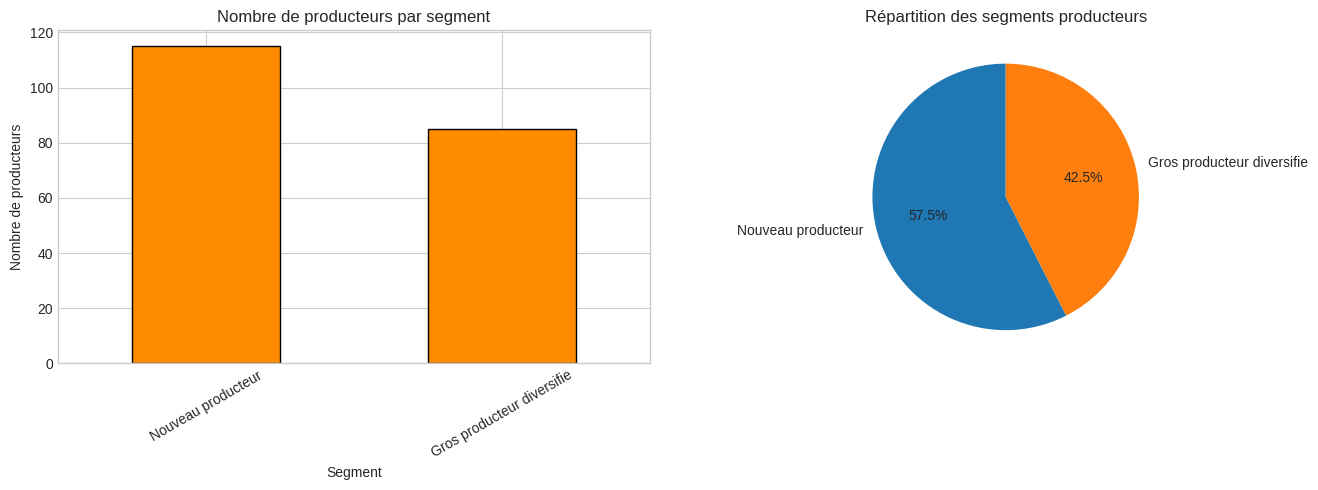

In [7]:
producers = query("SELECT * FROM v_current_producer_segments")
print(f"Total producteurs segmentés : {len(producers)}")
print()

dist_p = producers["cluster_label"].value_counts()
print(dist_p)
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

dist_p.plot(kind="bar", ax=ax1, color="darkorange", edgecolor="black")
ax1.set_title("Nombre de producteurs par segment")
ax1.set_xlabel("Segment")
ax1.set_ylabel("Nombre de producteurs")
ax1.tick_params(axis="x", rotation=30)

dist_p.plot(kind="pie", ax=ax2, autopct="%1.1f%%", startangle=90)
ax2.set_ylabel("")
ax2.set_title("Répartition des segments producteurs")

plt.tight_layout()
plt.show()

## 7. Profil moyen des clusters producteurs

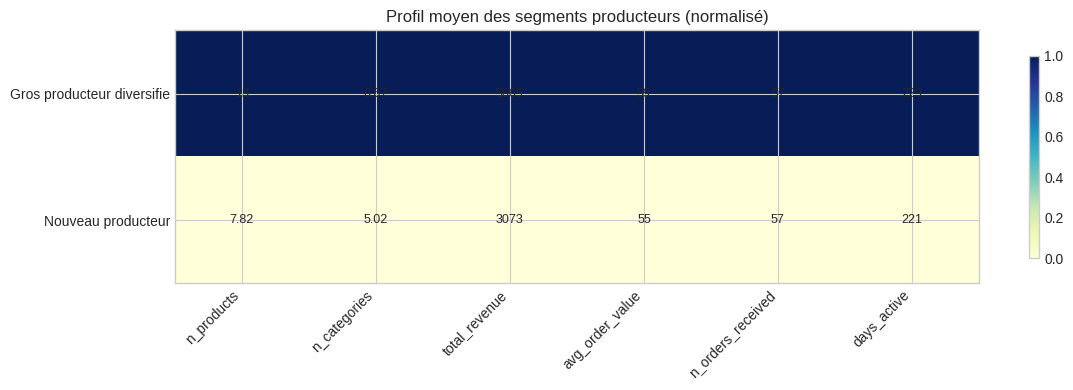

,n_products,n_categories,total_revenue,avg_order_value,n_orders_received,days_active
cluster_label,,,,,,
Gros producteur diversifie,12.95,6.67,5669.39,59.09,97.31,228.71
Nouveau producteur,7.82,5.02,3072.91,55.19,57.29,220.74


In [8]:
features_p = ["n_products", "n_categories", "total_revenue",
              "avg_order_value", "n_orders_received", "days_active"]

profiles_p = producers.groupby("cluster_label")[features_p].mean()
profiles_p_norm = (profiles_p - profiles_p.min()) / (profiles_p.max() - profiles_p.min())

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(profiles_p_norm.values, cmap="YlGnBu", aspect="auto")

ax.set_xticks(range(len(features_p)))
ax.set_xticklabels(features_p, rotation=45, ha="right")
ax.set_yticks(range(len(profiles_p)))
ax.set_yticklabels(profiles_p.index)
ax.set_title("Profil moyen des segments producteurs (normalisé)")

for i in range(len(profiles_p)):
    for j in range(len(features_p)):
        val = profiles_p.values[i, j]
        fmt = ".0f" if val > 10 else ".2f"
        ax.text(j, i, f"{val:{fmt}}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

profiles_p.round(2)

## 8. Distribution géographique des segments producteurs

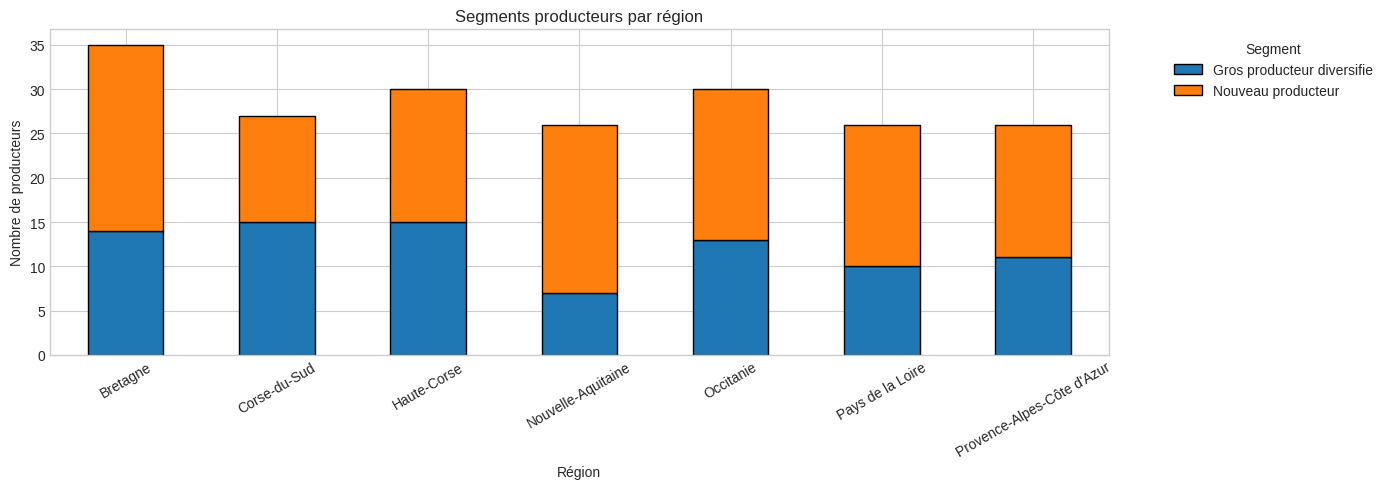

In [9]:
geo = producers.groupby(["location_region", "cluster_label"]).size().unstack(fill_value=0)

geo.plot(kind="bar", stacked=True, figsize=(14, 5), edgecolor="black")
plt.title("Segments producteurs par région")
plt.xlabel("Région")
plt.ylabel("Nombre de producteurs")
plt.xticks(rotation=30)
plt.legend(title="Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()